## Mushroom Type Prediction with Machine Learning (All-in-One Notebook)

### DataSet :



- `cap_diameter:` The diameter of the mushroom cap.
- `cap_shape:` The shape of the mushroom cap, encoded as integers.
- `gill_attachment:` The attachment of the gills, encoded as integers.
- `gill_color:` The color of the gills, encoded as integers.
- `stem_height:` The height of the mushroom stem.
- `stem_width` The width of the mushroom stem.
- `stem_color:` The color of the mushroom stem, encoded as integers.
- `season:` The season when the mushroom was found, encoded as integers.
- `class:` The classification of the mushroom, where 0 indicates edible and 1 indicates poisonous.


**Dataset credits:** Prisha Sawhney (https://www.kaggle.com/datasets/prishasawhney/mushroom-dataset/data)

In [72]:
#import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

### 1: Data Preparation and Exploration



In [37]:
df = pd.read_csv("mushroom_classification.csv")

print(f"Rows : {df.shape[0]}    Columns : {df.shape[1]}")
print("Few rows of data set :")
df.head(10)

Rows : 54035    Columns : 9
Few rows of data set :


,cap_diameter,cap_shape,gill_attachment,gill_color,stem_height,stem_width,stem_color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1
5,1337,6,2,10,3.775635,1520,11,0.943195,1
6,1300,2,2,10,3.835320,1563,11,1.804273,1
7,1354,6,2,10,3.676160,1532,11,0.888450,1
8,1222,6,2,10,3.771656,1476,11,0.943195,1
9,1085,6,2,10,3.775635,1581,11,0.888450,1


### 2: Exploratory Data Analysis (EDA)



In [79]:
df.isna().sum()

cap_diameter       0
cap_shape          0
gill_attachment    0
gill_color         0
stem_height        0
stem_width         0
stem_color         0
season             0
class              0
dtype: int64

In [38]:
grouped_data = df.groupby("class")[["cap_diameter", "stem_height" , "stem_width"]].mean()
grouped_data

,cap_diameter,stem_height,stem_width
class,,,
0,633.064696,0.627374,1208.915189
1,513.236293,0.867251,921.516563


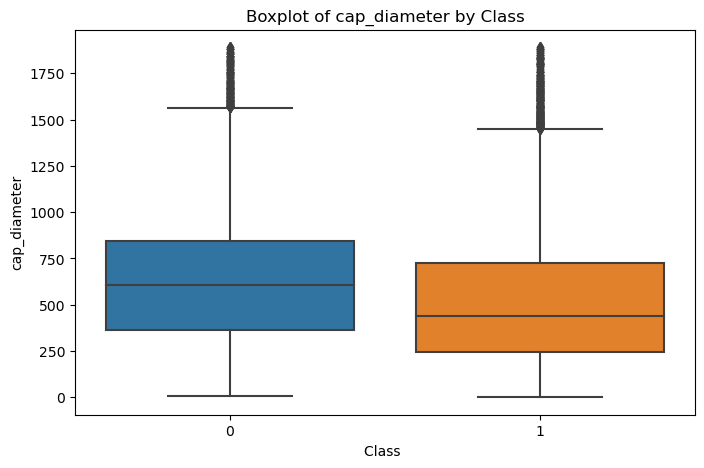

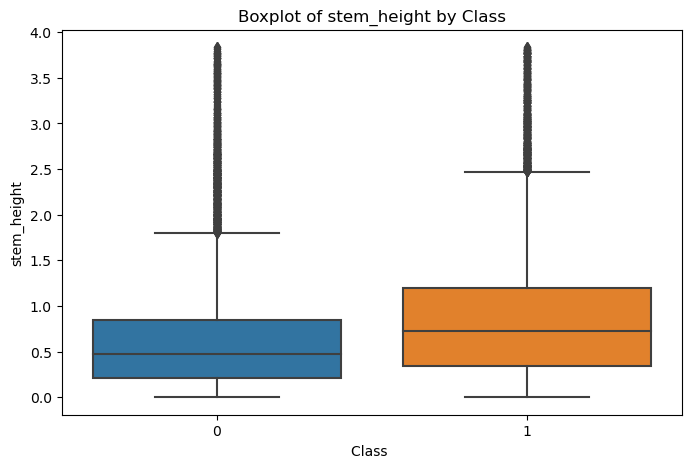

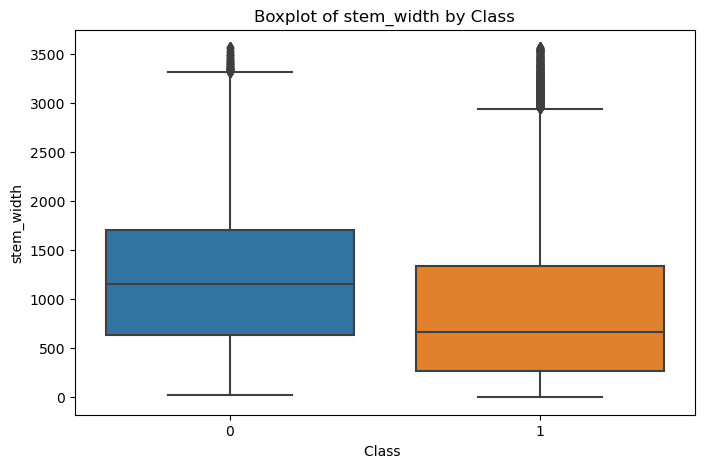

In [67]:
features_to_analyze = ["cap_diameter", "stem_height", "stem_width"]

for feature in features_to_analyze:
    plt.figure(figsize=(8, 5))  
    sns.boxplot(x='class', y=feature, data=df)
    plt.title(f"Boxplot of {feature} by Class")
    plt.xlabel("Class ")
    plt.ylabel(feature)
    plt.show()

###  3: Model Training Using Basic Models


In [40]:
# Select the features and target variable for modeling
X = df.drop('class' , axis = 1)
y = df['class']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 42)

In [42]:
model = LogisticRegression()
model.fit(X_train , y_train)

y_pred = model.predict(X_test)

print("Classification Report :")
print(classification_report(y_test , y_pred))

Classification Report :
              precision    recall  f1-score   support

           0       0.61      0.55      0.58      6130
           1       0.66      0.71      0.68      7379

    accuracy                           0.64     13509
   macro avg       0.63      0.63      0.63     13509
weighted avg       0.64      0.64      0.64     13509



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
# Initialize and train a Decision Tree Classifier model using the training data
model = DecisionTreeClassifier()
model.fit(X_train , y_train)

y_pred = model.predict(X_test)

print("Classification Report :")
print(classification_report(y_test , y_pred))


Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      6130
           1       0.98      0.98      0.98      7379

    accuracy                           0.98     13509
   macro avg       0.98      0.98      0.98     13509
weighted avg       0.98      0.98      0.98     13509



### 4: Model Training Using Gradient Boosting Classifier



In [47]:
# Initialize and train a Gradient Boosting Classifier model using the training data
model = GradientBoostingClassifier()
model.fit(X_train , y_train)

y_pred = model.predict(X_test)

print("Classification Report :")
print(classification_report(y_test , y_pred))


Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      6130
           1       0.89      0.89      0.89      7379

    accuracy                           0.88     13509
   macro avg       0.88      0.88      0.88     13509
weighted avg       0.88      0.88      0.88     13509



Text(0.5, 0, 'Importance')

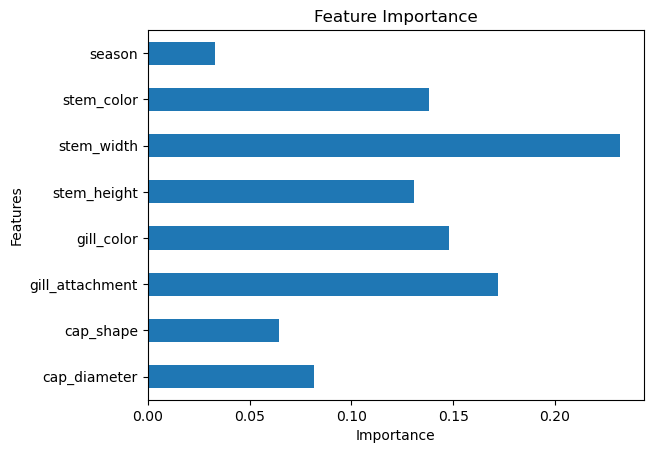

In [69]:
# Calculate and display the feature importances GB Model
importance = pd.Series(model.feature_importances_ ,index = X.columns)
importance.plot(kind = 'barh')
plt.title("Feature Importance")
plt.ylabel("Features")
plt.xlabel("Importance")

### 5: Exploring Various Parameters in Gradient Boosting Classifier

In [60]:
# assign specifi parameters
gb_params = {
    'learning_rate': 0.05,
    'n_estimators': 400,
    'max_depth': 5,
    'min_samples_split': 3,
    'min_samples_leaf': 2
}
model = GradientBoostingClassifier(**gb_params)
model.fit(X_train , y_train)

y_pred = model.predict(X_test)

print("Classification Report :")
print(classification_report(y_test , y_pred))


Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6130
           1       0.98      0.98      0.98      7379

    accuracy                           0.98     13509
   macro avg       0.98      0.98      0.98     13509
weighted avg       0.98      0.98      0.98     13509



Text(0.5, 1.0, 'Custom GB Model Confusion Matrix')

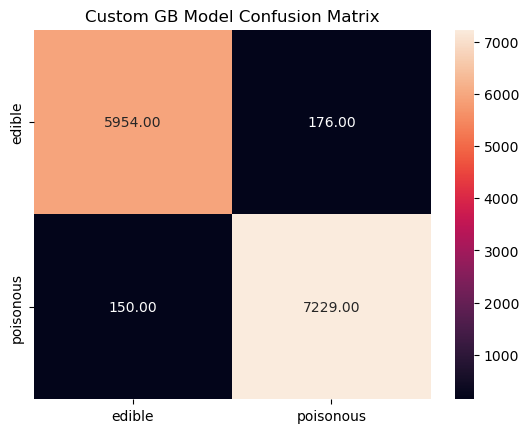

In [78]:
cm = confusion_matrix(y_test , y_pred)
labels = ['edible', 'poisonous']
sns.heatmap(cm , annot = True , xticklabels =labels , yticklabels = labels , fmt = ".2f" )
plt.title("Custom GB Model Confusion Matrix")


### Conclusion

1. **Logistic Regression**  
   - Accuracy: 0.64

2. **Decision Tree Classifier**  
   - Accuracy: 0.98

3. **Gradient Boosting Classifier**  
   - Accuracy with Standard Parameters: 0.88  
   - Accuracy with Custom Parameters: 0.98
<br></br>
Overall, the Decision Tree Classifier and the Gradient Boosting model with custom parameters both demonstrated strong performance, with the Gradient Boosting model showing a slight improvement with parameter tuning.